911 Calls Analysis
----------------------------------------------------------------------------------------------------------

This dataset contains the following fields:
* lat : String variable, Latitude
* lng: String variable, Longitude
* desc: String variable, Description of the Emergency Call
* zip: String variable, Zipcode
* title: String variable, Title
* timeStamp: String variable, YYYY-MM-DD HH:MM:SS
* twp: String variable, Township
* addr: String variable, Address
* e: String variable, Dummy variable (always 1)


---------------------------------------------------------------

    Setup:

In [79]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('whitegrid')
%matplotlib inline

In [80]:
df = pd.read_csv('911.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   lat        99492 non-null  float64
 1   lng        99492 non-null  float64
 2   desc       99492 non-null  object 
 3   zip        86637 non-null  float64
 4   title      99492 non-null  object 
 5   timeStamp  99492 non-null  object 
 6   twp        99449 non-null  object 
 7   addr       98973 non-null  object 
 8   e          99492 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 6.8+ MB


In [81]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:40:00,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:40:00,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 17:40:00,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 17:40:01,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 17:40:01,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


-----------------------------------------------------------------------------------------------------

    Questions:

1. What are the top 5 zipcodes for 911 calls?

In [82]:
df['zip'].value_counts().head(5)

zip
19401.0    6979
19464.0    6643
19403.0    4854
19446.0    4748
19406.0    3174
Name: count, dtype: int64

2. What are the top 5 townships for 911 calls?

In [83]:
df['twp'].value_counts().head()

twp
LOWER MERION    8443
ABINGTON        5977
NORRISTOWN      5890
UPPER MERION    5227
CHELTENHAM      4575
Name: count, dtype: int64

-------------------------

    Adding Features:

Creating a "Reasons" column to classify each call as EMS/Fire/Traffic

In [84]:
df['Reason'] = df['title'].apply(lambda title: title.split(":")[0])

In [85]:
df['Reason'].value_counts()

Reason
EMS        48877
Traffic    35695
Fire       14920
Name: count, dtype: int64

In [86]:
df['Reason'].head()

0     EMS
1     EMS
2    Fire
3     EMS
4     EMS
Name: Reason, dtype: object

Creating countplot of 911 calls by Reason

<Axes: xlabel='Reason', ylabel='count'>

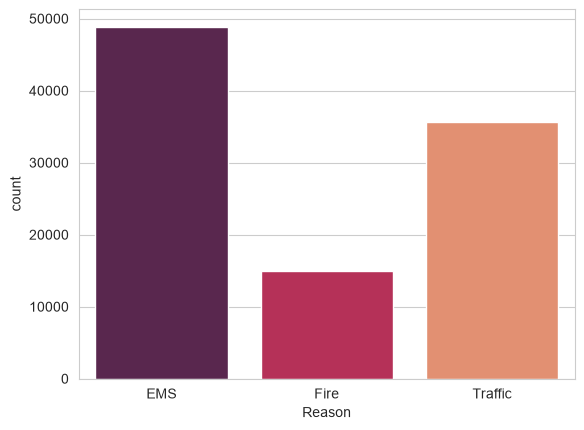

In [87]:
sns.countplot(x='Reason', data= df, hue= 'Reason', palette= 'rocket')

----------------------------------------------------------------------------------------------------------

Converting timestamps to DateTime objects

In [88]:
df['timeStamp']= pd.to_datetime(df['timeStamp'])

In [89]:
df['Hour'] = df['timeStamp'].apply(lambda time: time.hour)
df['Month'] = df['timeStamp'].apply(lambda time: time.month)
df['Day'] = df['timeStamp'].apply(lambda time: time.day)

Converting days of the week to names instead of numbers.

In [90]:
dmap = {1:'Mon', 2:'Tue', 3:'Wed', 4:'Thu', 5:'Fri', 6:'Sat', 7:'Sun'}
df['Day'] = df['Day'].map(dmap)

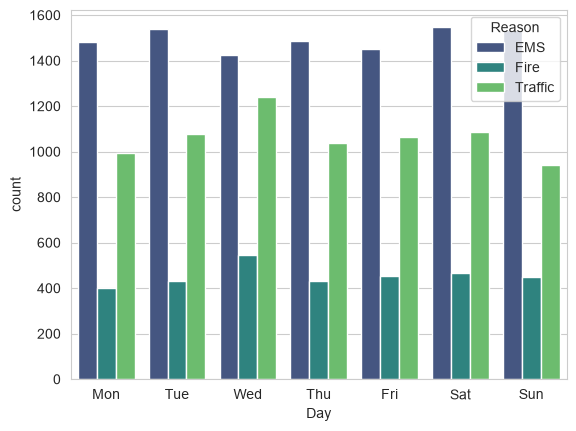

In [91]:
sns.countplot(x= 'Day', data= df, hue= 'Reason', palette='viridis')
plt.show()

<Axes: xlabel='Month', ylabel='count'>

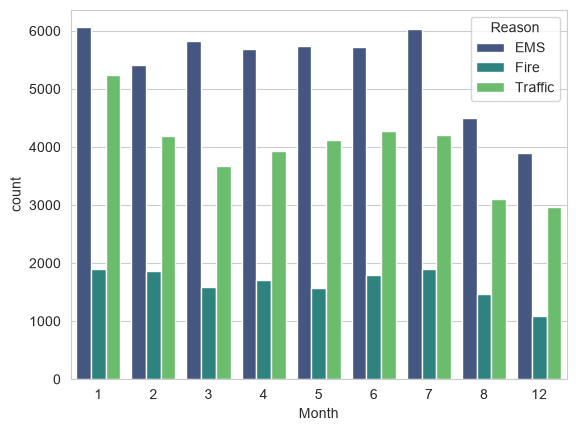

In [92]:
sns.countplot(x='Month', hue='Reason', data= df, palette= 'viridis')

As we can see, the countplot is missing data for the months of September, October, and November. This doesn't mean that there were no calls during these months, it just means that there is some missing data. We will use a simple line plot to fill this gap. 

In [93]:
byMonth = df.groupby('Month').count()
byMonth.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e,Reason,Hour,Day
Month,,,,,,,,,,,,
1,13205,13205,13205,11527,13205,13205,13203,13096,13205,13205,13205,2591
2,11467,11467,11467,9930,11467,11467,11465,11396,11467,11467,11467,2651
3,11101,11101,11101,9755,11101,11101,11092,11059,11101,11101,11101,2508
4,11326,11326,11326,9895,11326,11326,11323,11283,11326,11326,11326,2958
5,11423,11423,11423,9946,11423,11423,11420,11378,11423,11423,11423,2332


<Axes: xlabel='Month'>

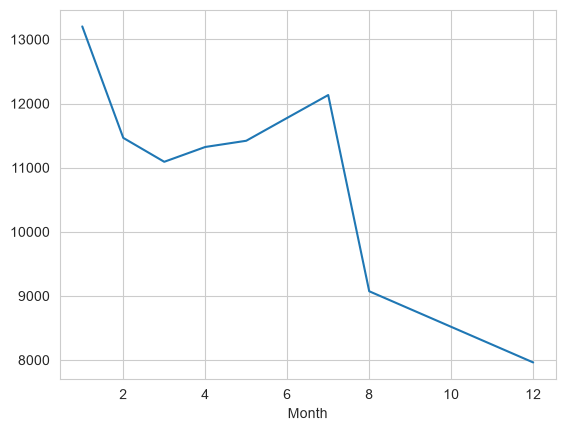

In [94]:
byMonth['twp'].plot()

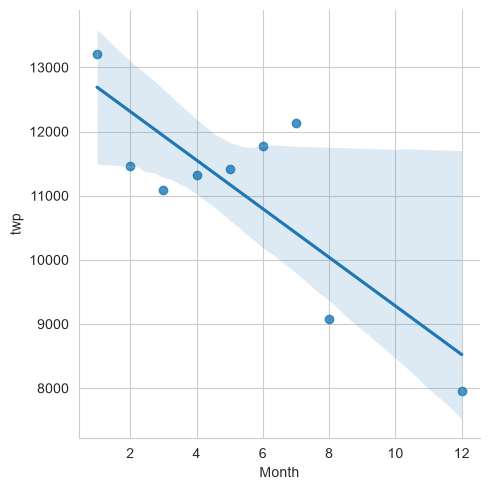

In [95]:
sns.lmplot(x='Month',y='twp',data=byMonth.reset_index())